In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Telco_Customer_Churn_clean.csv')

X = df.drop('Churn', axis=1)
y = df['Churn']

In [2]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
import pickle

with open("final_xgb_model_artifact.pkl", "rb") as f:
    model_artifact = pickle.load(f)

final_xgb_model = model_artifact["model"]

#### Xgboost built-in feature importance
- By gain

In [4]:
feat_imp_gain = final_xgb_model.get_booster().get_score(importance_type='gain')

In [5]:
keys = list(feat_imp_gain.keys())
values = list(feat_imp_gain.values())

df_feat_imp_gain = pd.DataFrame(data=values, index=keys, columns=['score']).sort_values(by='score', ascending= False)
df_feat_imp_gain

,score
InternetService_Fiber optic,30.448614
Contract_Two year,20.198069
InternetService_No,13.907171
Contract_One year,9.206908
PaymentMethod_Electronic check,8.175900
tenure,5.376055
StreamingMovies_Yes,4.637469
OnlineSecurity_Yes,4.008651
PaperlessBilling,3.943962
PhoneService,3.853923


#### Plot the 10 most important features

<Axes: title={'center': 'Feature importance by gain'}>

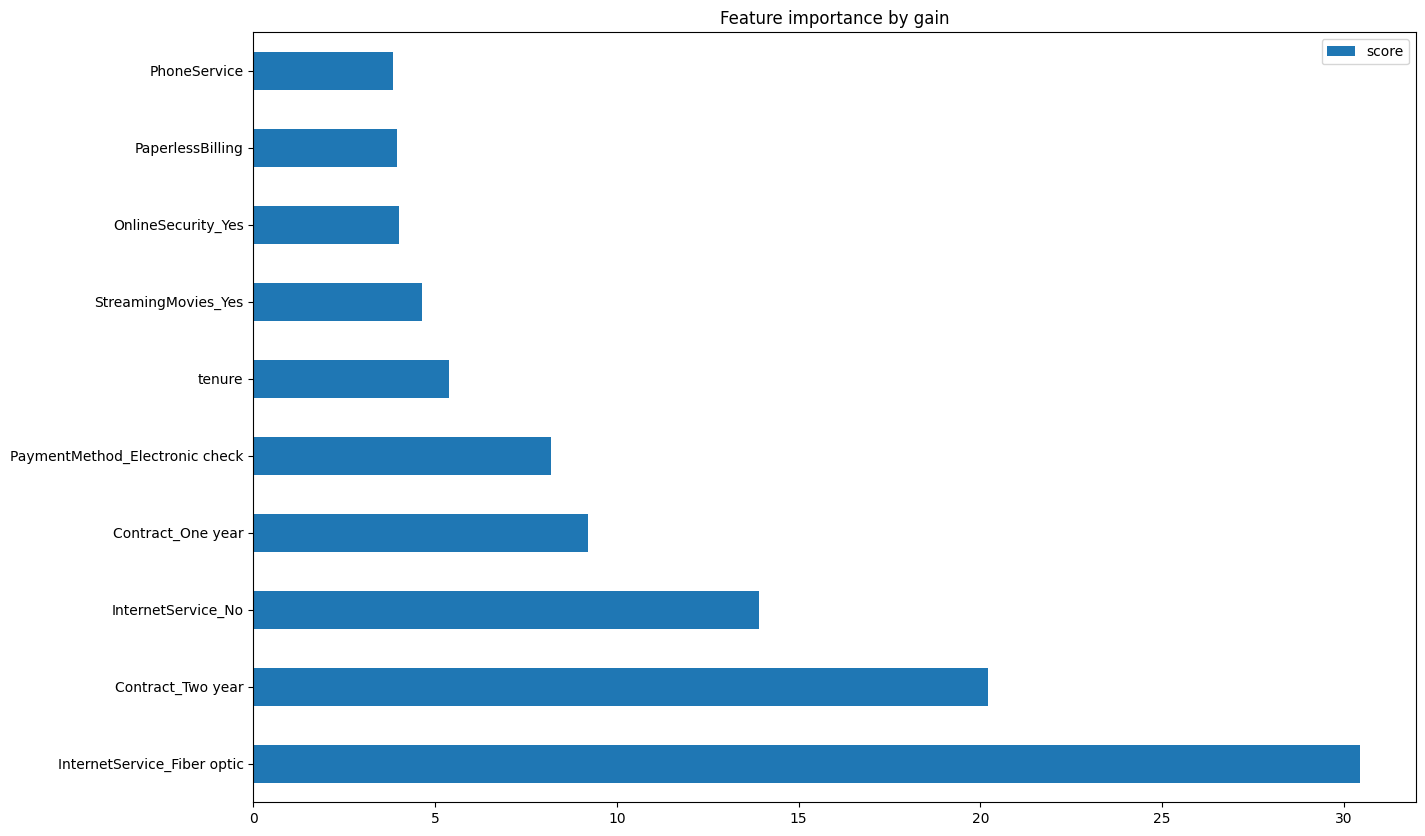

In [6]:
df_feat_imp_gain.nlargest(10, columns='score').plot(kind='barh',figsize=(15,10), title='Feature importance by gain')

- weight

In [7]:
feat_imp_weight = final_xgb_model.get_booster().get_score(importance_type='weight')

keys = list(feat_imp_weight.keys())
values = list(feat_imp_weight.values())

df_feat_imp_weight = pd.DataFrame(data=values, index=keys, columns=['score']).sort_values(by='score', ascending= False)
df_feat_imp_weight

,score
MonthlyCharges,1676.0
TotalCharges,1451.0
tenure,864.0
gender,148.0
PaperlessBilling,127.0
PaymentMethod_Electronic check,126.0
Dependents,118.0
OnlineBackup_Yes,116.0
OnlineSecurity_Yes,114.0
Contract_One year,107.0


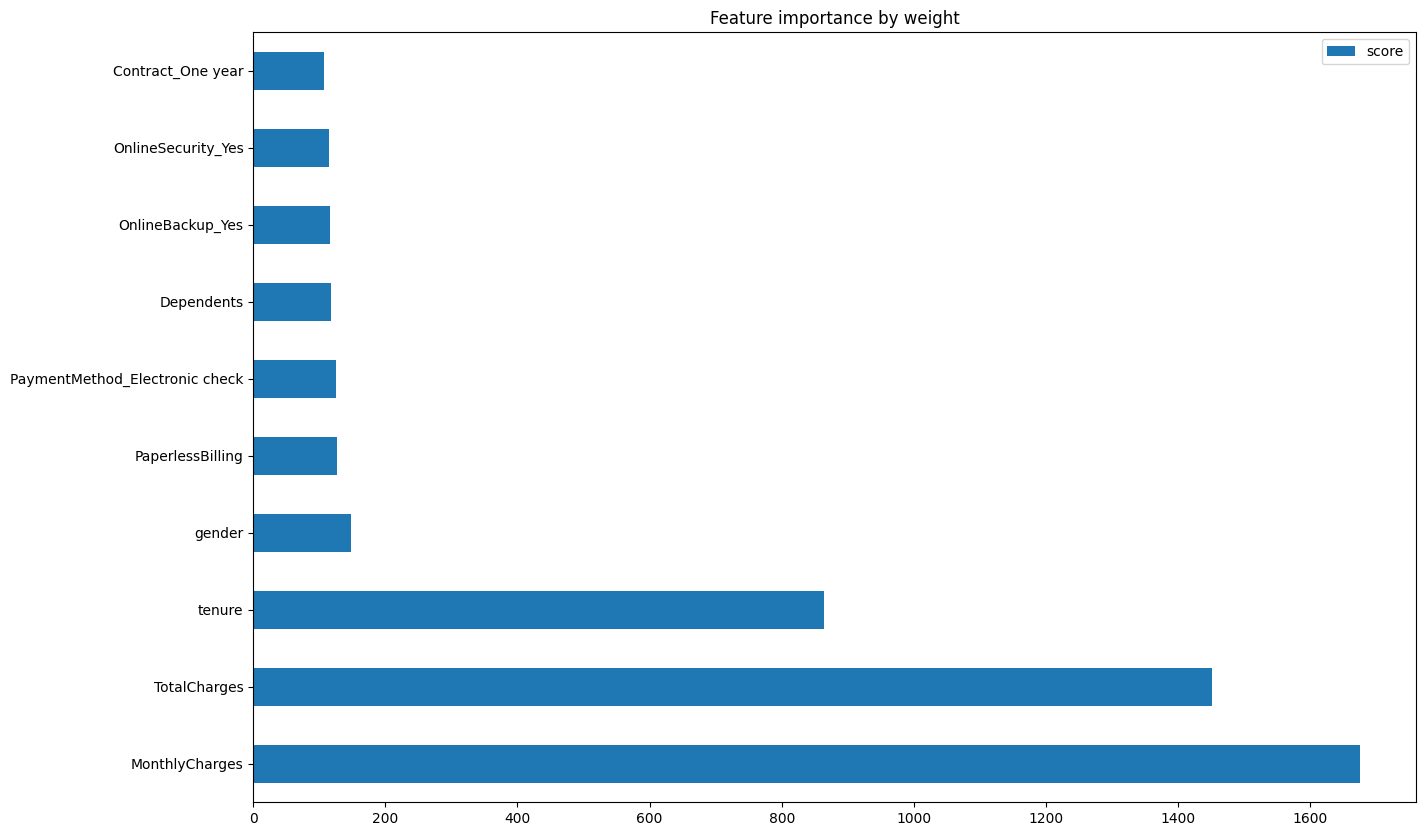

In [8]:
df_feat_imp_weight.nlargest(10, columns='score').plot(kind='barh',figsize=(15,10), title='Feature importance by weight')
plt.show()

## Feature importance using SHAP

In [9]:
import shap

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
explainer = shap.TreeExplainer(final_xgb_model)
shap_values = explainer.shap_values(X_test)

#### Let's see if shap values add up to the predictions

In [11]:
import numpy as np

shap_sum = shap_values.sum(axis = 1)+explainer.expected_value
shap_sum_prob = 1/(1 + np.exp(-1 * shap_sum))
y_test_prob = final_xgb_model.predict_proba(X_test)[:,1]

df_shap_sum = pd.DataFrame({
    'SHAP Sum': shap_sum_prob,
    'predicted probability':y_test_prob
})
df_shap_sum.sample(10)

,SHAP Sum,predicted probability
709,0.111242,0.111242
511,0.057409,0.057410
192,0.001472,0.001472
225,0.002747,0.002747
1006,0.092363,0.092363
427,0.724289,0.724289
573,0.097638,0.097638
832,0.007964,0.007964
268,0.043272,0.043272
482,0.183317,0.183317


In [12]:
# check using numpy allclose function
np.allclose(shap_sum_prob, y_test_prob)

True

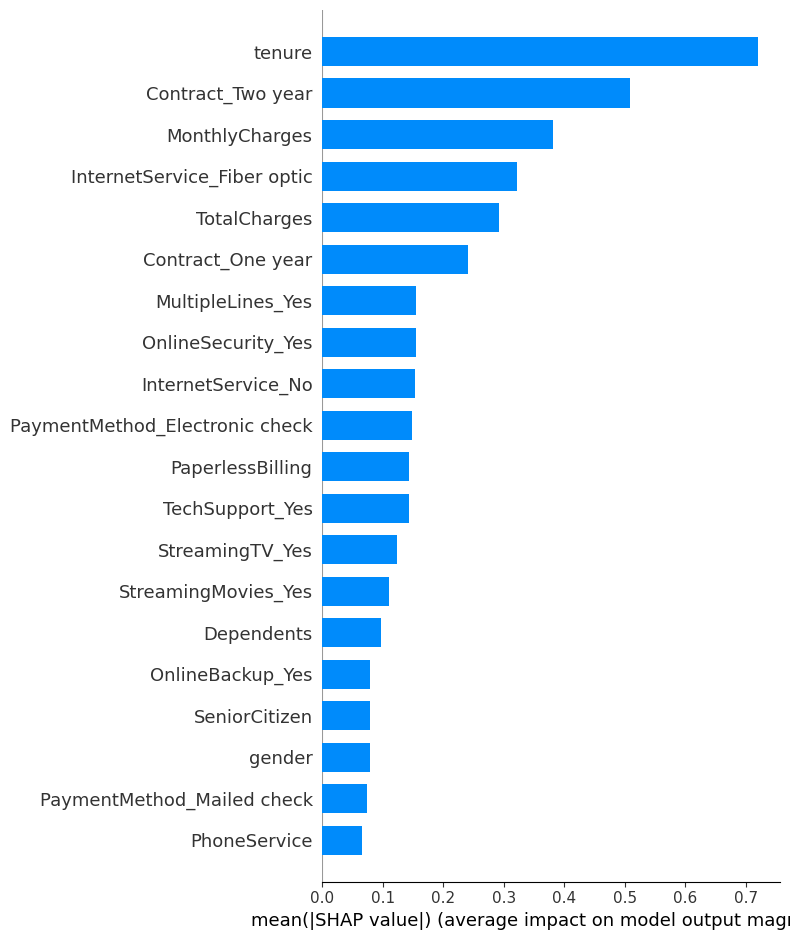

In [13]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

The top 4 features by F statistic we found by ANOVA F-Test were: `tenure, InternetService_Fiber optic, Contract_Two year, PaymentMethod_Electronic check`. These are also the top 4 features which are contributing the most as we see in the bar plot above.

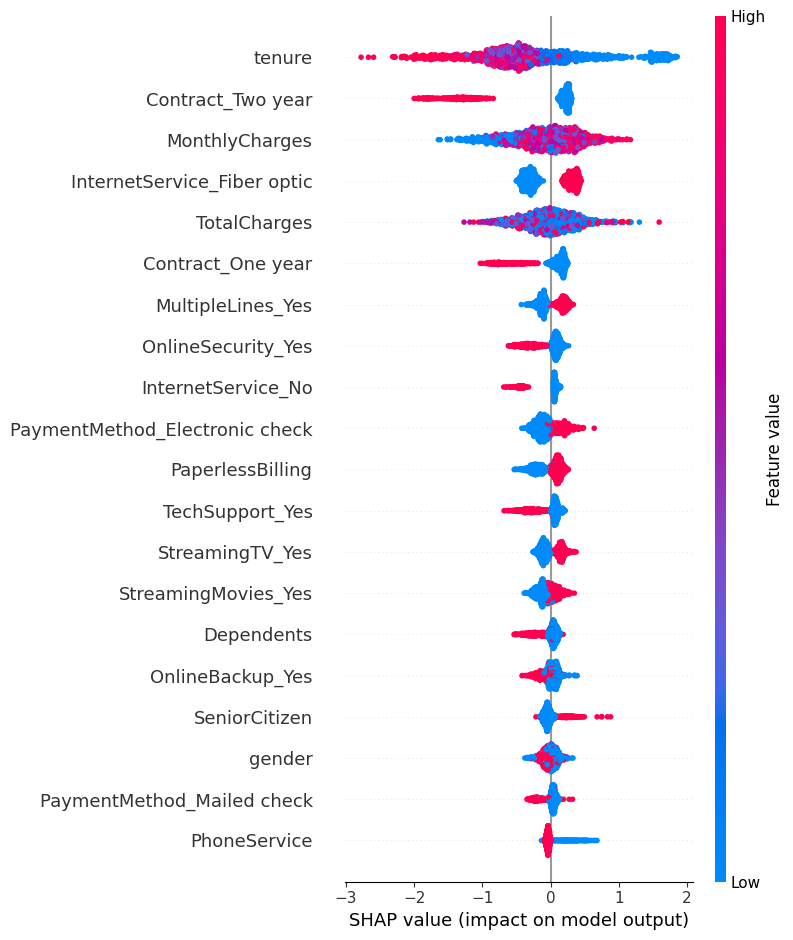

In [14]:
shap.summary_plot(shap_values, X_test)

Let us look at the scatter plot of SHAP values for the tenure column

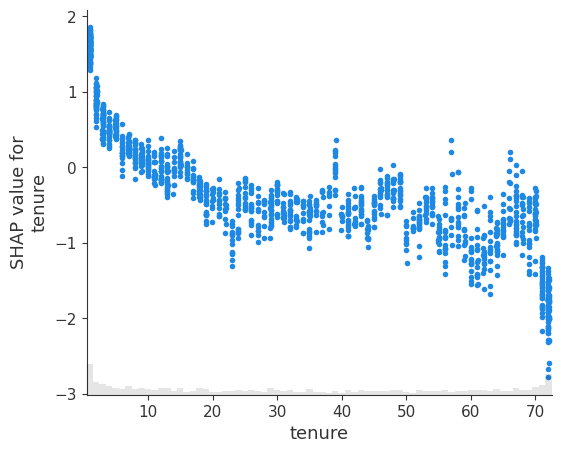

In [15]:
tenure_idx = df.columns.get_loc('tenure')
shap.plots.scatter(explainer(X_test)[:,'tenure'])

The SHAP dependence plot for tenure shows a clear nonlinear negative relationship with churn prediction. Customers with very low tenure have large positive SHAP values, indicating that early-tenure customers strongly increase predicted churn risk. As tenure increases, the SHAP contribution steadily becomes negative, showing that longer-tenure customers are less likely to churn. The transition occurs around 15–20 months, suggesting that the first year to year-and-a-half is the critical retention window. This supports a business strategy focused on onboarding, early engagement, and proactive retention interventions for new customers.

Now let's color the scatter plot above by the feature with which it has highest interaction

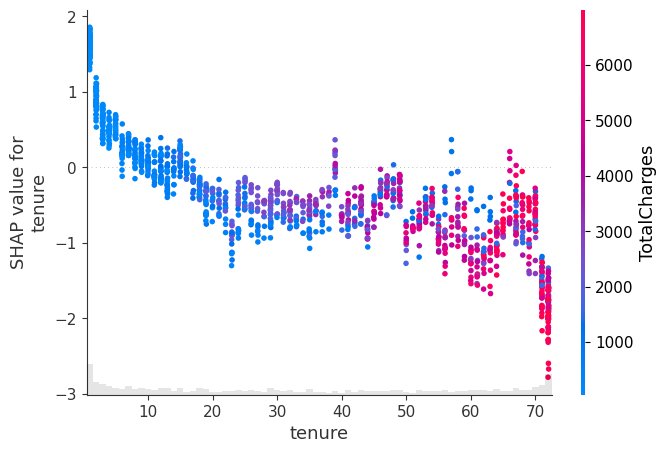

In [16]:
shap.plots.scatter(explainer(X_test)[:,'tenure'], color=explainer(X_test))

SHAP dependence analysis shows that tenure is one of the strongest churn drivers. New customers have large positive SHAP values, increasing predicted churn risk, especially within the first few months. As tenure increases, the SHAP contribution becomes increasingly negative, indicating that longer-tenure customers are less likely to churn. The color gradient shows that high-tenure customers also tend to have higher TotalCharges, suggesting an interaction where long-standing, high-value customers are more stable. This supports a retention strategy focused on early-lifecycle customers, especially within the first 12–20 months.